<a href="https://colab.research.google.com/github/jeetjohngomes77-svg/fake-news-detection/blob/main/Fake_News_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection
### IDEAS TIH Summer Internship 2026 — Section 2
### Intern: Jeet John Gomes
### Mentor: Dr. Dipasree Pal

## Project Overview
This project aims to detect whether a news article is real or fake
using classical machine learning techniques.

## Importing Libraries

We first import all the necessary libraries and modules required for data handling, visualization, text processing, and machine learning.

**Data Handling & Numerical Operations**
- **pandas (`pd`)**: For loading, manipulating, and analyzing structured data (like CSVs) using DataFrames.
- **numpy (`np`)**: For fast mathematical operations and handling multidimensional arrays.

**Data Visualization**
- **matplotlib.pyplot (`plt`)**: The core library for creating static, animated, and interactive plots.
- **seaborn (`sns`)**: Built on top of matplotlib, it provides a high-level interface for drawing attractive statistical graphics (like heatmaps for confusion matrices).

**Data Preprocessing**
- **train_test_split**: A utility to randomly divide our dataset into a training set (to teach the model) and a testing set (to evaluate it).
- **TfidfVectorizer**: Converts raw text into a matrix of TF-IDF (Term Frequency-Inverse Document Frequency) features, transforming words into numbers the models can understand.

**Machine Learning Models**
- **LogisticRegression**: A straightforward linear model used for binary or multiclass classification.
- **MultinomialNB**: A Naive Bayes classifier that works exceptionally well for text classification based on word counts or TF-IDF.
- **SVC (Support Vector Classifier)**: A powerful model that finds the best boundary (hyperplane) to separate different text categories.

**Model Evaluation & Utilities**
- **accuracy_score, confusion_matrix, classification_report**: A suite of metrics to thoroughly evaluate how well our models are predicting the right classes.
- **time**: A built-in Python module we will use to measure and compare how long each model takes to train and predict.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
import time

##  Loading the Dataset
We load two CSV files from Kaggle:
- True.csv: contains real news articles
- Fake.csv: contains fake news articles

We then label them — 1 for real news and 0 for fake news.

In [ ]:

!pip install kaggle --quiet

import os
from google.colab import userdata


os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

#!kaggle datasets list


In [ ]:
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset
!unzip -o fake-and-real-news-dataset.zip -d data

Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
fake-and-real-news-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  fake-and-real-news-dataset.zip
  inflating: data/Fake.csv           
  inflating: data/True.csv           


In [ ]:
fake_df = pd.read_csv('./data/Fake.csv')
true_df = pd.read_csv('./data/True.csv')

true_df['label'] = 1  # 1 means Real news
fake_df['label'] = 0  # 0 means Fake news

print("Real news articles:", true_df.shape)
print("Fake news articles:", fake_df.shape)

Real news articles: (21417, 5)
Fake news articles: (23481, 5)


##  Exploring the Dataset
Before preprocessing we look at the structure of our data to
understand what columns we have and what the data looks like.

In [ ]:
print("Real News Sample:")
print(true_df.head())

print("\nFake News Sample:")
print(fake_df.head())

print("\nColumns in dataset:", true_df.columns.tolist())

Real News Sample:
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  label  
0  December 31, 2017       1  
1  December 29, 2017       1  
2  December 31, 2017       1  
3  December 30, 2017       1  
4  December 29, 2017       1  

Fake News Sample:
                   

## Combining and Preprocessing the Data

We combine both datasets into one and then clean the text by:
1. Lowercasing all text so "Trump" and "trump" are treated the same
2. Removing punctuation which adds no meaning to the text
3. Removing duplicate articles to prevent the model from memorizing repeated content
4. Removing URLs since they are just random strings that don't help detect fake news
5. Removing numbers since dates and statistics rarely help generalize patterns
6. Removing extra whitespace left behind after the above cleaning steps
7. Shuffling the dataset so real and fake articles are randomly mixed before splitting into train and test sets

Note: Stopword removal was moved to the TF-IDF Vectorization step using the stop_words parameter, so it is no longer done manually here.

In [ ]:
df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.drop_duplicates(subset='text')
print("After removing duplicates:", df.shape[0])
df['content'] = df['title'] + ' ' + df['text']
df['content'] = df['content'].str.lower()
df['content'] = df['content'].str.replace(r'http\S+|www\S+', '', regex=True)
df['content'] = df['content'].str.replace(r'[^\w\s]', '', regex=True)
df['content'] = df['content'].str.replace(r'\d+', '', regex=True)
df['content'] = df['content'].str.replace(r'\s+', ' ', regex=True).str.strip()
df = df.reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Final dataset size:", df.shape[0])
print("\nLabel distribution after cleaning:")
print(df['label'].value_counts())

After removing duplicates: 38646
Final dataset size: 38646

Label distribution after cleaning:
label
1    21192
0    17454
Name: count, dtype: int64


## Graph 1: Distribution of Real vs Fake News Articles

After combining and cleaning the dataset we check how many
real and fake news articles we have. This is important because:

- A balanced dataset means the model gets equal exposure to
  both real and fake news during training
- If one class had significantly more articles than the other,
  the model would be biased towards predicting that class more
  often, leading to misleading accuracy scores

From the graph we can observe that after removing 6,252 duplicate
articles our dataset contains:
- 21,192 real news articles
- 17,454 fake news articles

The dataset is reasonably balanced which means our model will
not be significantly biased towards either class during training.

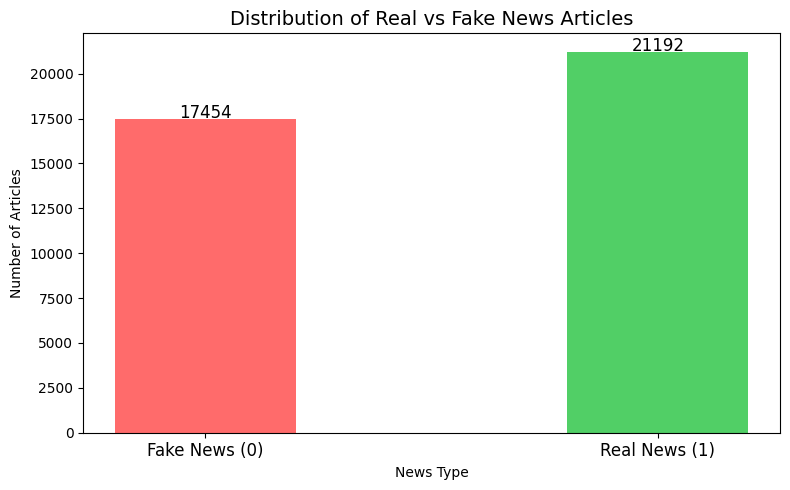

In [ ]:
labels = ['Fake News (0)', 'Real News (1)']
counts = [df['label'].value_counts()[0], df['label'].value_counts()[1]]
colors = ['#ff6b6b', '#51cf66']

plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color=colors, width=0.4)
plt.title('Distribution of Real vs Fake News Articles', fontsize=14)
plt.xlabel('News Type')
plt.ylabel('Number of Articles')
plt.xticks(fontsize=12)

for i, count in enumerate(counts):
    plt.text(i, count + 100, str(count), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## Graph 2: Proportion of News Categories

This pie chart shows the percentage share of each news category
in our entire dataset of 38,646 articles.

The dataset contains 6 categories:
- politicsNews: 29.0% — the largest category
- worldnews: 25.8% — the second largest category
- News: 23.4% — general news articles
- politics: 16.6% — political news articles
- left-news: 1.3% — left leaning news articles
- Government News: 1.2% — government related articles
- US_News: 2.0% — US specific news articles

Key observations:
- The dataset is heavily dominated by political content —
  politicsNews and politics together make up nearly 46% of
  all articles
- worldnews is the second most represented category at 25.8%
- left-news, Government News and US_News are very small
  categories each making up less than 2% of the dataset
- Since political news dominates our dataset, our model is
  likely better trained to detect fake political news than
  other categories

We use a pie chart here because it clearly shows the relative
proportion of each category compared to the whole dataset at
a glance.

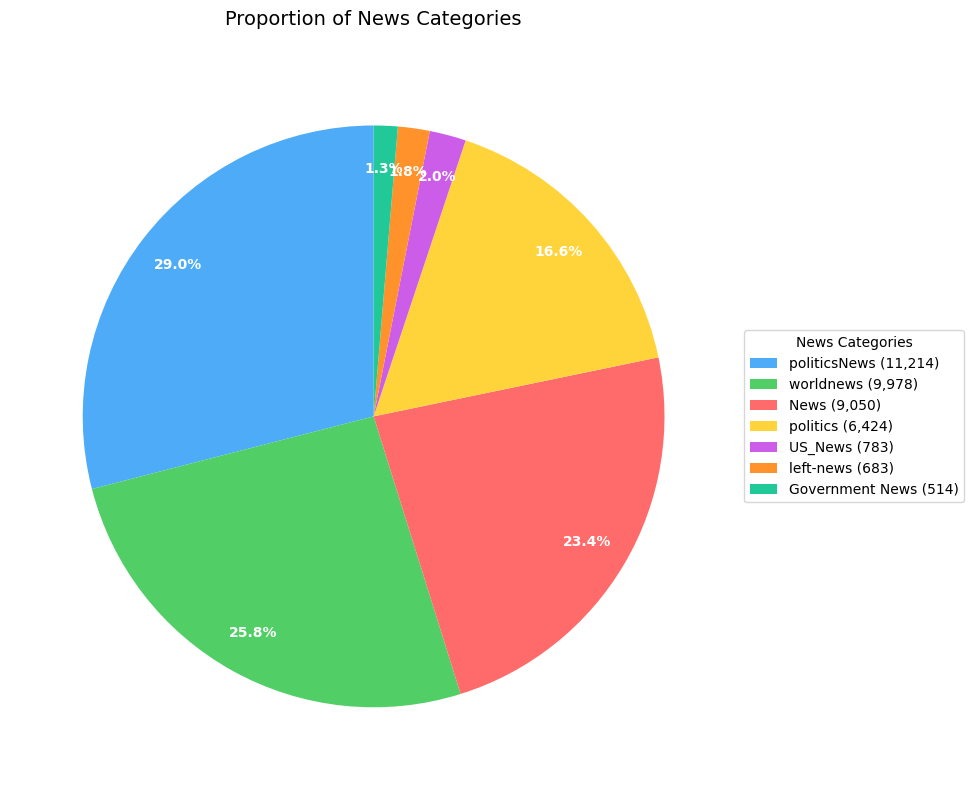

In [ ]:

plt.figure(figsize=(12, 8))
category_counts = df['subject'].value_counts()

wedges, texts, autotexts = plt.pie(
    category_counts.values,
    labels=None,
    autopct='%1.1f%%',
    colors=['#4dabf7', '#51cf66', '#ff6b6b',
            '#ffd43b', '#cc5de8', '#ff922b', '#20c997'],
    startangle=90,
    pctdistance=0.85
)
\
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')


plt.legend(
    wedges,
    [f'{label} ({count:,})'
     for label, count in zip(category_counts.index,
                             category_counts.values)],
    title='News Categories',
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10
)

plt.title('Proportion of News Categories', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

##  Splitting the Data
We split our data into:
- Training set (80%): used to train the model
- Testing set (20%): used to evaluate the model on unseen data
This is standard statistical practice to avoid overfitting.

In [ ]:
X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 30916
Testing samples: 7730


##  TF-IDF Vectorization
TF-IDF stands for Term Frequency - Inverse Document Frequency.
It is a statistical technique that converts text into numbers.
- Term Frequency: how often a word appears in an article
- Inverse Document Frequency: reduces weight of words that appear
  in almost every article
This helps the model focus on words that are truly meaningful for
distinguishing fake from real news.

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Shape of TF-IDF training matrix:", X_train_tfidf.shape)

Shape of TF-IDF training matrix: (30916, 5000)


##  Training the Logistic Regression Model
Logistic Regression is a statistical classification algorithm.
It calculates the probability that a news article belongs to
a particular class (real or fake) and assigns it accordingly.
It is well suited for binary classification problems like ours.

In [ ]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

print("Model training complete!")

Model training complete!


##  Evaluating the Logistic Regression Model
We evaluate our model using:
- Accuracy: percentage of correct predictions
- Confusion Matrix: shows exactly what types of errors the model made
- Classification Report: shows precision, recall and F1 score

In [ ]:
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Fake News', 'Real News']))

Accuracy: 0.9892626131953428

Confusion Matrix:
[[3431   63]
 [  20 4216]]

Classification Report:
              precision    recall  f1-score   support

   Fake News       0.99      0.98      0.99      3494
   Real News       0.99      1.00      0.99      4236

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



## Graph 3: Logistic Regression -- Confusion Matrix

A confusion matrix is a table that shows exactly how well our
model performed by comparing its predictions against the actual
correct labels.

We display it as a heatmap because:
- Colors make it immediately clear which cells have high vs
  low values
- Darker blue cells indicate higher counts
- It is much easier to interpret visually than raw numbers alone

The heatmap has 4 cells:

- Top Left: Fake news correctly predicted as Fake (True Positive)
- Top Right: Fake news wrongly predicted as Real (False Negative)
- Bottom Left: Real news wrongly predicted as Fake (False Positive)
- Bottom Right: Real news correctly predicted as Real (True Negative)

Ideally we want the top left and bottom right cells to be as
dark as possible (high correct predictions) and the top right
and bottom left cells to be as light as possible (low incorrect
predictions).

Our model was evaluated on 7,730 test articles. The heatmap
clearly shows that the vast majority of articles were correctly
classified, reflected in the dark diagonal cells, while the
off-diagonal cells representing mistakes are very light,
indicating very few misclassifications.

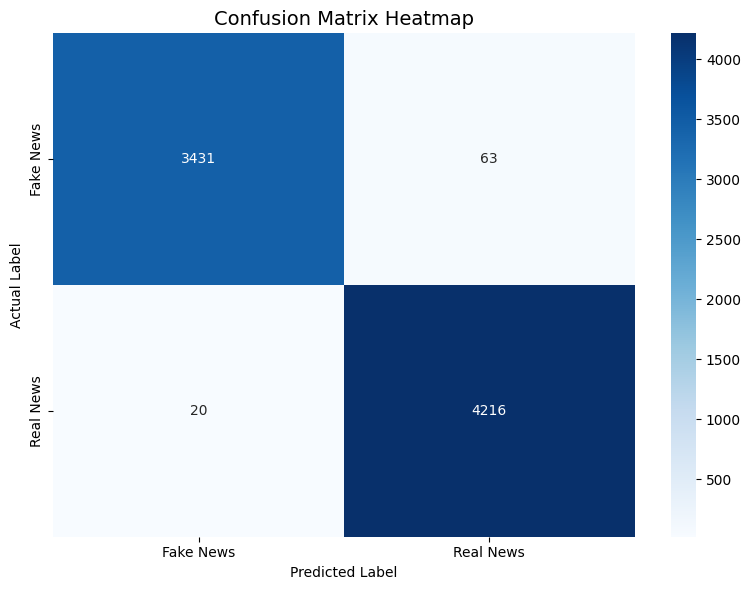

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake News', 'Real News'],
            yticklabels=['Fake News', 'Real News'])
plt.title('Confusion Matrix Heatmap', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Training the Naive Bayes Model

Naive Bayes is a probabilistic classification algorithm
based on Bayes Theorem from statistics. It is one of the
oldest and most widely used algorithms for text
classification problems.

The word "Naive" comes from its key assumption — it
assumes that all words in an article are completely
independent of each other. For example it assumes that
the presence of the word "trump" in an article has no
influence on whether the word "election" also appears.
This assumption is not entirely true in real language,
but surprisingly it still works very well in practice
for text classification.

We use MultinomialNB which is specifically designed for
text data with word count or TF-IDF features.

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes training complete!")

Naive Bayes training complete!


##  Evaluating the Naive Bayes Model
We evaluate our model using:
- Accuracy: percentage of correct predictions
- Confusion Matrix: shows exactly what types of errors the model made
- Classification Report: shows precision, recall and F1 score

In [ ]:
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb,
      target_names=['Fake News', 'Real News']))

Accuracy: 0.9446313065976714

Confusion Matrix:
[[3278  216]
 [ 212 4024]]

Classification Report:
              precision    recall  f1-score   support

   Fake News       0.94      0.94      0.94      3494
   Real News       0.95      0.95      0.95      4236

    accuracy                           0.94      7730
   macro avg       0.94      0.94      0.94      7730
weighted avg       0.94      0.94      0.94      7730



## Graph 4: Naive Bayes — Confusion Matrix

The confusion matrix below shows exactly how Naive Bayes
performed on our 7,730 test articles, broken down into
four categories:

- Top Left: Fake articles correctly identified as Fake
- Top Right: Fake articles wrongly identified as Real
  (missed fake news)
- Bottom Left: Real articles wrongly identified as Fake
  (wrongly censored)
- Bottom Right: Real articles correctly identified as Real

We use the YlOrBr (Yellow Orange Brown) color scheme to
visually distinguish it from our Logistic Regression
confusion matrix (Blue) making it easy to compare both
matrices side by side.

Darker cells indicate higher counts — ideally the diagonal
cells (top left and bottom right) should be the darkest,
meaning most articles were correctly classified.

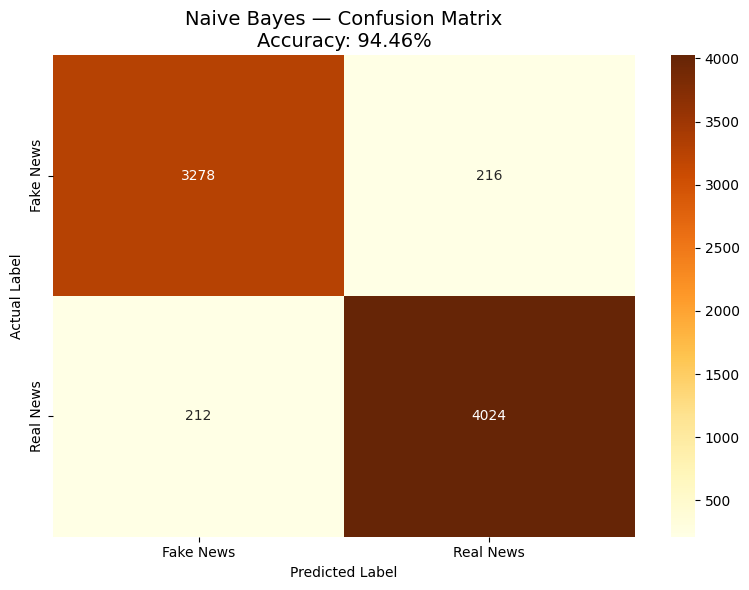

In [ ]:
plt.figure(figsize=(8, 6))
cm_nb = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Fake News', 'Real News'],
            yticklabels=['Fake News', 'Real News'])

plt.title(f'Naive Bayes — Confusion Matrix\nAccuracy: {accuracy_score(y_test, y_pred_nb)*100:.2f}%',
          fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Trainning the Decision Tree Model

A Decision Tree makes predictions by asking a series of
yes/no questions about word features, similar to a
flowchart. It learns which words best split fake news
from real news at each branch point during training.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_tfidf, y_train)

print("Decision Tree training complete!")

Decision Tree training complete!


##  Evaluating the Decision Tree Classifier
We evaluate our model using:
- Accuracy: percentage of correct predictions
- Confusion Matrix: shows exactly what types of errors the model made
- Classification Report: shows precision, recall and F1 score

In [ ]:
y_pred_dt = dt_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt,
      target_names=['Fake News', 'Real News']))

Accuracy: 0.9928848641655886

Confusion Matrix:
[[3463   31]
 [  24 4212]]

Classification Report:
              precision    recall  f1-score   support

   Fake News       0.99      0.99      0.99      3494
   Real News       0.99      0.99      0.99      4236

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



## Graph 5: Decision tree — Confusion Matrix

The confusion matrix below shows exactly how Naive Bayes
performed on our 7,730 test articles, broken down into
four categories:

- Top Left: Fake articles correctly identified as Fake
- Top Right: Fake articles wrongly identified as Real
  (missed fake news)
- Bottom Left: Real articles wrongly identified as Fake
  (wrongly censored)
- Bottom Right: Real articles correctly identified as Real


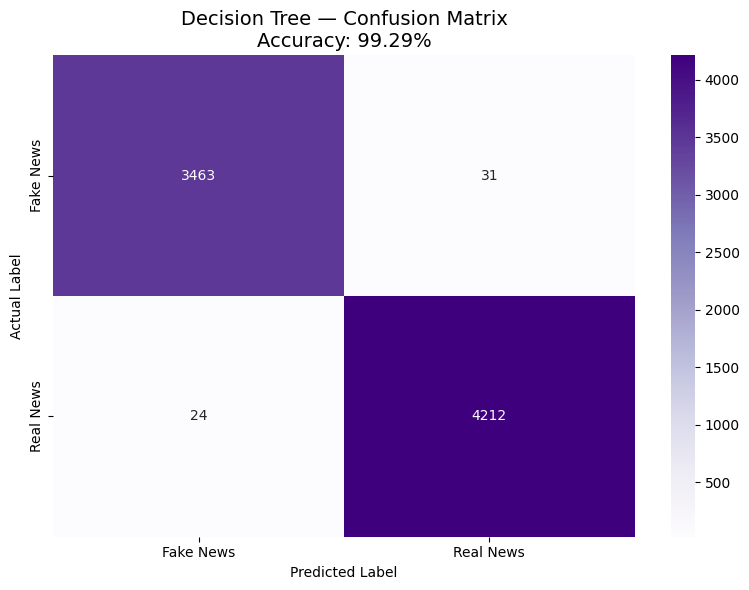

In [ ]:
plt.figure(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Fake News', 'Real News'],
            yticklabels=['Fake News', 'Real News'])

plt.title(f'Decision Tree — Confusion Matrix\nAccuracy: {accuracy_score(y_test, y_pred_dt)*100:.2f}%',
          fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Custom News Prediction

We test all three trained models on a custom news
article input to see how each model predicts in
real time.

In [ ]:
def predict_news(news_text):
    # Vectorize
    news_tfidf = tfidf.transform([news_text.lower()])

    # Logistic Regression
    lr_pred = model.predict(news_tfidf)[0]
    lr_conf = max(model.predict_proba(news_tfidf)[0]) * 100

    # Naive Bayes
    nb_pred = nb_model.predict(news_tfidf)[0]
    nb_conf = max(nb_model.predict_proba(news_tfidf)[0]) * 100

    # Decision Tree
    dt_pred = dt_model.predict(news_tfidf)[0]
    dt_conf = max(dt_model.predict_proba(news_tfidf)[0]) * 100

    print("=" * 50)
    print("Logistic Regression:")
    print("REAL NEWS" if lr_pred == 1 else "FAKE NEWS")
    print(f"Confidence: {lr_conf:.2f}%")

    print("\nNaive Bayes:")
    print("REAL NEWS" if nb_pred == 1 else "FAKE NEWS")
    print(f"Confidence: {nb_conf:.2f}%")

    print("\nDecision Tree:")
    print("REAL NEWS" if dt_pred == 1 else "FAKE NEWS")
    print(f"Confidence: {dt_conf:.2f}%")
    print("=" * 50)

predict_news("The new education minister is amit shah")

Logistic Regression:
REAL NEWS
Confidence: 82.17%

Naive Bayes:
REAL NEWS
Confidence: 82.89%

Decision Tree:
FAKE NEWS
Confidence: 100.00%
